In [ ]:
markers =['GRM3', 'WIF1', 'TMEM132C', 'ADAMTS17', 'CACNA1A', 'OAF', 'EPHA4', 'FOXG1', 'LHX2', 'CSPG5', 'SLIT1', 'EMX2', # GM STR
          'SLC6A11', 'ADCY1', 'CDH23', 'PTPRJ', # GM exSTR
          'DCLK1', 'ADAMTSL3', 'COL21A1', 'SLC38A1', 'CCDC85A', 'KCNJ3', 'GALNT15', 'STXBP5L', 'MAN1C1', 'ANGPT1','CPAMD8', 'SLCO3A1', 'SMAD9', 'CREB5', # WM 
          'SLC1A2', 'SLC1A3', 'NRXN1', 'GPC5', 'GLUL','PTCH1',  # GM 
          'TNC', 'GFAP', 'DPP6', 'TSHZ2', 'RGS6', # GM exSTR + WM
          'DPP10']

In [2]:
import pandas as pd
import numpy as np

# -----------------------------
# Input files
# -----------------------------
primary_deseq2_file = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Subgroup_DEGs_pseudobulk-DESeq2.csv"

cellbender_deseq2_file = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Subgroup_DEGs_pseudobulk-DESeq2-afterCB.csv"

# -----------------------------
# Output files
# -----------------------------
output_table = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Table_S2_DESeq2_markers_retained_after_CellBender_copy.csv"

output_marker_summary = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Selected_subgroup_marker_changes.csv"

# -----------------------------
# Marker list
# -----------------------------
markers = [
    'GRM3', 'WIF1', 'TMEM132C', 'ADAMTS17', 'CACNA1A', 'OAF',
    'EPHA4', 'FOXG1', 'LHX2', 'CSPG5', 'SLIT1', 'EMX2',  # GM STR

    'SLC6A11', 'ADCY1', 'CDH23', 'PTPRJ',  # GM exSTR

    'DCLK1', 'ADAMTSL3', 'COL21A1', 'SLC38A1', 'CCDC85A',
    'KCNJ3', 'GALNT15', 'STXBP5L', 'MAN1C1', 'ANGPT1',
    'CPAMD8', 'SLCO3A1', 'SMAD9', 'CREB5',  # WM

    'SLC1A2', 'SLC1A3', 'NRXN1', 'GPC5', 'GLUL', 'PTCH1',  # GM

    'TNC', 'GFAP', 'DPP6', 'TSHZ2', 'RGS6',  # GM exSTR + WM

    'DPP10'
]

# -----------------------------
# Read tables
# -----------------------------
primary = pd.read_csv(primary_deseq2_file)
cb = pd.read_csv(cellbender_deseq2_file)

for df in [primary, cb]:
    df["group"] = df["group"].astype(str)
    df["gene"] = df["gene"].astype(str)

# -----------------------------
# Keep CellBender columns
# -----------------------------
cb_cols_to_add = [
    "group",
    "gene",
    "baseMean",
    "log2FoldChange",
    "lfcSE",
    "stat",
    "pvalue",
    "padj"
]

cb_cols_to_add = [c for c in cb_cols_to_add if c in cb.columns]

cb_add = cb[cb_cols_to_add].copy()

# -----------------------------
# Rename CellBender columns
# -----------------------------
rename_cb = {
    "baseMean": "CellBender_baseMean",
    "log2FoldChange": "CellBender_log2FoldChange",
    "lfcSE": "CellBender_lfcSE",
    "stat": "CellBender_stat",
    "pvalue": "CellBender_pvalue",
    "padj": "CellBender_padj"
}

cb_add = cb_add.rename(columns=rename_cb)

# -----------------------------
# Merge tables
# -----------------------------
table_s2 = primary.merge(
    cb_add,
    on=["group", "gene"],
    how="inner"
)

# -----------------------------
# Rename primary columns
# -----------------------------
rename_primary = {
    "baseMean": "primary_baseMean",
    "log2FoldChange": "primary_log2FoldChange",
    "lfcSE": "primary_lfcSE",
    "stat": "primary_stat",
    "pvalue": "primary_pvalue",
    "padj": "primary_padj"
}

table_s2 = table_s2.rename(columns=rename_primary)

# -----------------------------
# Effect size concordance
# -----------------------------
table_s2["delta_log2FoldChange_CellBender_minus_primary"] = (
    table_s2["CellBender_log2FoldChange"]
    - table_s2["primary_log2FoldChange"]
)

table_s2["abs_delta_log2FoldChange"] = (
    table_s2["delta_log2FoldChange_CellBender_minus_primary"].abs()
)

table_s2["same_log2FC_direction"] = (
    table_s2["primary_log2FoldChange"]
    * table_s2["CellBender_log2FoldChange"] > 0
)

# -----------------------------
# Significance concordance
# -----------------------------
table_s2["primary_minuslog10_padj"] = -np.log10(
    table_s2["primary_padj"].clip(lower=1e-300)
)

table_s2["CellBender_minuslog10_padj"] = -np.log10(
    table_s2["CellBender_padj"].clip(lower=1e-300)
)

table_s2["delta_minuslog10_padj"] = (
    table_s2["CellBender_minuslog10_padj"]
    - table_s2["primary_minuslog10_padj"]
)

# -----------------------------
# Sort full table
# -----------------------------
sort_cols = [
    c for c in ["group", "primary_padj", "gene"]
    if c in table_s2.columns
]

table_s2 = table_s2.sort_values(sort_cols)

# -----------------------------
# Save full merged table
# -----------------------------
table_s2.to_csv(output_table, index=False)

print("Saved full table:")
print(output_table)

print("\nRows:", table_s2.shape[0])
print("Columns:", table_s2.shape[1])

print("\nSame log2FC direction:",
      table_s2["same_log2FC_direction"].sum())

print("Different direction:",
      (~table_s2["same_log2FC_direction"]).sum())

# =====================================================
# Extract selected subgroup markers
# =====================================================
marker_df = table_s2[
    table_s2["gene"].isin(markers)
].copy()

# -----------------------------
# Sort marker table
# -----------------------------
marker_df = marker_df.sort_values(
    ["group", "abs_delta_log2FoldChange"],
    ascending=[True, False]
)

# -----------------------------
# Save concise marker summary
# -----------------------------
summary_cols = [
    "group",
    "gene",

    "primary_log2FoldChange",
    "CellBender_log2FoldChange",
    "delta_log2FoldChange_CellBender_minus_primary",
    "abs_delta_log2FoldChange",
    "same_log2FC_direction",

    "primary_padj",
    "CellBender_padj",

    "primary_minuslog10_padj",
    "CellBender_minuslog10_padj",
    "delta_minuslog10_padj"
]

summary_cols = [
    c for c in summary_cols
    if c in marker_df.columns
]

marker_df[summary_cols].to_csv(
    output_marker_summary,
    index=False
)

print("\nSaved marker summary:")
print(output_marker_summary)

# -----------------------------
# Quick subgroup summary
# -----------------------------
print("\nSubgroup-level log2FC stability:")
print(
    marker_df.groupby("group")[
        "abs_delta_log2FoldChange"
    ].describe()
)

print("\nGenes with flipped log2FC direction:")
print(
    marker_df.loc[
        ~marker_df["same_log2FC_direction"],
        ["group", "gene",
         "primary_log2FoldChange",
         "CellBender_log2FoldChange"]
    ]
)

Saved full table:
/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Table_S2_DESeq2_markers_retained_after_CellBender_copy.csv

Rows: 5763
Columns: 21

Same log2FC direction: 5763
Different direction: 0

Saved marker summary:
/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Selected_subgroup_marker_changes.csv

Subgroup-level log2FC stability:
          count      mean       std       min       25%       50%       75%  \
group                                                                         
GM STR     17.0  0.238598  0.383434  0.014947  0.030235  0.034530  0.340749   
GM exSTR    9.0  0.073312  0.120215  0.003176  0.005841  0.015070  0.079235   
WM         19.0  0.229682  0.248206  0.065937  0.073424  0.082351  0.296917   

               max  
group               
GM STR    1.393956  
GM exSTR  0.367933  
WM        0.960189  

Genes with flipped log2FC direction:
Empty DataFrame
Columns: [group, gene, primary_log2FoldChange, CellBender_log2Fo

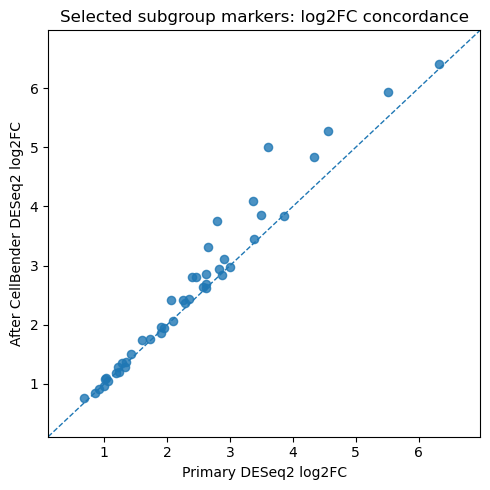

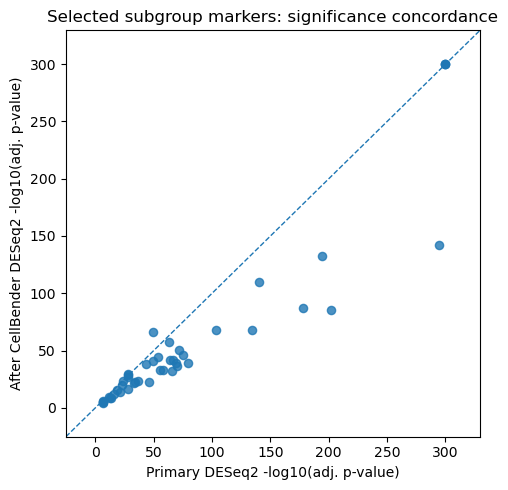

In [3]:
import matplotlib.pyplot as plt

plot_df = marker_df.copy()

# -----------------------------
# Plot 1: log2FC before vs after
# -----------------------------
fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(
    plot_df["primary_log2FoldChange"],
    plot_df["CellBender_log2FoldChange"],
    s=35,
    alpha=0.8
)

# diagonal
min_val = min(
    plot_df["primary_log2FoldChange"].min(),
    plot_df["CellBender_log2FoldChange"].min()
)
max_val = max(
    plot_df["primary_log2FoldChange"].max(),
    plot_df["CellBender_log2FoldChange"].max()
)

pad = 0.1 * (max_val - min_val)
lims = [min_val - pad, max_val + pad]

ax.plot(lims, lims, linestyle="--", linewidth=1)

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Primary DESeq2 log2FC")
ax.set_ylabel("After CellBender DESeq2 log2FC")
ax.set_title("Selected subgroup markers: log2FC concordance")

plt.tight_layout()
plt.savefig(
    "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Selected_subgroup_markers_log2FC_scatter.pdf",
    bbox_inches="tight"
)
plt.show()


# -----------------------------
# Plot 2: -log10(padj) before vs after
# -----------------------------
fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(
    plot_df["primary_minuslog10_padj"],
    plot_df["CellBender_minuslog10_padj"],
    s=35,
    alpha=0.8
)

min_val = min(
    plot_df["primary_minuslog10_padj"].min(),
    plot_df["CellBender_minuslog10_padj"].min()
)
max_val = max(
    plot_df["primary_minuslog10_padj"].max(),
    plot_df["CellBender_minuslog10_padj"].max()
)

pad = 0.1 * (max_val - min_val)
lims = [min_val - pad, max_val + pad]

ax.plot(lims, lims, linestyle="--", linewidth=1)

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Primary DESeq2 -log10(adj. p-value)")
ax.set_ylabel("After CellBender DESeq2 -log10(adj. p-value)")
ax.set_title("Selected subgroup markers: significance concordance")

plt.tight_layout()
plt.savefig(
    "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Selected_subgroup_markers_padj_scatter.pdf",
    bbox_inches="tight"
)
plt.show()

In [ ]:
fig6b_gene_list = ['GRM3', 'WIF1', 'TMEM132C', 'ADRA1A', 'CHI3L1', 'CD44', 'SERPINA3', 'GADD45A', 'SLC39A14', 'FOS', 'ADAMTS9', 'VAV3', 'GFAP', 'DCHS2', 'TMEM108', 'ARMC3', 'CRLF1', 'NTN1', 'CSMD3', 'SLC9A6', 'DCDC1', 'CRYM']

Selected rows: 18
Saved: /home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Fig6B_Human7_14_31_marker_changes.csv

Rows by cluster:
cluster
Human-31    9
Human-7     8
Human-14    1
Name: count, dtype: int64

Missing genes from selected table:
['CRYM', 'GRM3', 'TMEM132C', 'WIF1']

Genes with flipped log2FC direction:
Empty DataFrame
Columns: [cluster, gene, primary_log2FoldChange, CellBender_log2FoldChange]
Index: []


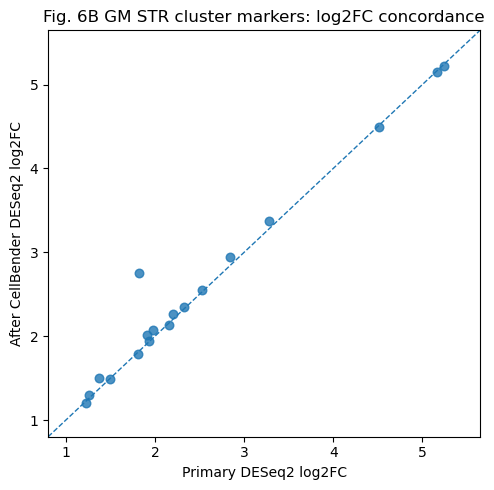

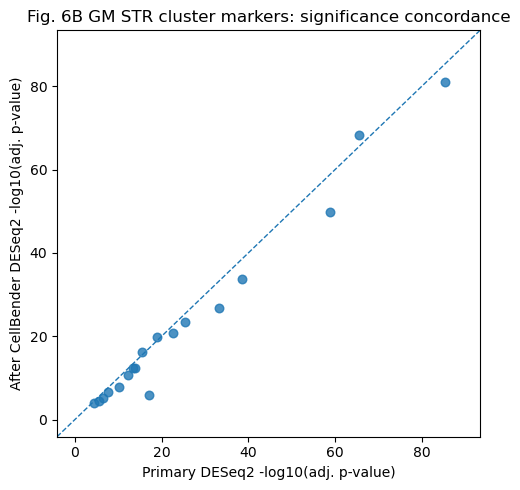

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Input
# -----------------------------
cluster_table_file = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Table_S1_DESeq2_markers_retained_after_CellBender.csv"

# -----------------------------
# Output
# -----------------------------
output_selected_csv = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Fig6B_Human7_14_31_marker_changes.csv"

output_log2fc_pdf = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Fig6B_Human7_14_31_log2FC_scatter.pdf"

output_padj_pdf = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Fig6B_Human7_14_31_padj_scatter.pdf"

# -----------------------------
# Genes and clusters
# -----------------------------
fig6b_gene_list = [
    'GRM3', 'WIF1', 'TMEM132C', 'ADRA1A', 'CHI3L1', 'CD44',
    'SERPINA3', 'GADD45A', 'SLC39A14', 'FOS', 'ADAMTS9',
    'VAV3', 'GFAP', 'DCHS2', 'TMEM108', 'ARMC3', 'CRLF1',
    'NTN1', 'CSMD3', 'SLC9A6', 'DCDC1', 'CRYM'
]

target_clusters = ["Human-7", "Human-14", "Human-31"]

# -----------------------------
# Read table
# -----------------------------
df = pd.read_csv(cluster_table_file)

df["cluster"] = df["cluster"].astype(str)
df["gene"] = df["gene"].astype(str)

# -----------------------------
# Subset
# -----------------------------
plot_df = df[
    df["cluster"].isin(target_clusters)
    & df["gene"].isin(fig6b_gene_list)
].copy()

# -----------------------------
# Add helper columns if needed
# -----------------------------
if "primary_minuslog10_padj" not in plot_df.columns:
    plot_df["primary_minuslog10_padj"] = -np.log10(
        plot_df["primary_padj"].clip(lower=1e-300)
    )

if "CellBender_minuslog10_padj" not in plot_df.columns:
    plot_df["CellBender_minuslog10_padj"] = -np.log10(
        plot_df["CellBender_padj"].clip(lower=1e-300)
    )

if "delta_log2FoldChange_CellBender_minus_primary" not in plot_df.columns:
    plot_df["delta_log2FoldChange_CellBender_minus_primary"] = (
        plot_df["CellBender_log2FoldChange"]
        - plot_df["primary_log2FoldChange"]
    )

if "abs_delta_log2FoldChange" not in plot_df.columns:
    plot_df["abs_delta_log2FoldChange"] = (
        plot_df["delta_log2FoldChange_CellBender_minus_primary"].abs()
    )

if "same_log2FC_direction" not in plot_df.columns:
    plot_df["same_log2FC_direction"] = (
        plot_df["primary_log2FoldChange"]
        * plot_df["CellBender_log2FoldChange"] > 0
    )

# -----------------------------
# Save selected table
# -----------------------------
plot_df.to_csv(output_selected_csv, index=False)

print("Selected rows:", plot_df.shape[0])
print("Saved:", output_selected_csv)

print("\nRows by cluster:")
print(plot_df["cluster"].value_counts())

print("\nMissing genes from selected table:")
missing = sorted(set(fig6b_gene_list) - set(plot_df["gene"]))
print(missing)

print("\nGenes with flipped log2FC direction:")
print(
    plot_df.loc[
        ~plot_df["same_log2FC_direction"],
        ["cluster", "gene", "primary_log2FoldChange", "CellBender_log2FoldChange"]
    ]
)

# -----------------------------
# Scatter plotting function
# -----------------------------
def scatter_before_after(df, x_col, y_col, xlabel, ylabel, title, output_pdf):
    fig, ax = plt.subplots(figsize=(5, 5))

    ax.scatter(
        df[x_col],
        df[y_col],
        s=38,
        alpha=0.8
    )

    min_val = min(df[x_col].min(), df[y_col].min())
    max_val = max(df[x_col].max(), df[y_col].max())

    pad = 0.1 * (max_val - min_val)
    if pad == 0:
        pad = 0.5

    lims = [min_val - pad, max_val + pad]

    ax.plot(lims, lims, linestyle="--", linewidth=1)

    ax.set_xlim(lims)
    ax.set_ylim(lims)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    plt.tight_layout()
    plt.savefig(output_pdf, bbox_inches="tight")
    plt.show()

# -----------------------------
# Plot 1: log2FC concordance
# -----------------------------
scatter_before_after(
    plot_df,
    x_col="primary_log2FoldChange",
    y_col="CellBender_log2FoldChange",
    xlabel="Primary DESeq2 log2FC",
    ylabel="After CellBender DESeq2 log2FC",
    title="Fig. 6B GM STR cluster markers: log2FC concordance",
    output_pdf=output_log2fc_pdf
)

# -----------------------------
# Plot 2: significance concordance
# -----------------------------
scatter_before_after(
    plot_df,
    x_col="primary_minuslog10_padj",
    y_col="CellBender_minuslog10_padj",
    xlabel="Primary DESeq2 -log10(adj. p-value)",
    ylabel="After CellBender DESeq2 -log10(adj. p-value)",
    title="Fig. 6B GM STR cluster markers: significance concordance",
    output_pdf=output_padj_pdf
)